In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
names = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(url, names=names)

In [3]:
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric)
df = df.fillna(df.median())

In [4]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [5]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

In [7]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.9016 (90.16%)


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



In [9]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print("Top 3 Most Important Features:")
print(feat_imp.head(3))

Top 3 Most Important Features:
thal       0.139003
thalach    0.121375
cp         0.114075
dtype: float64


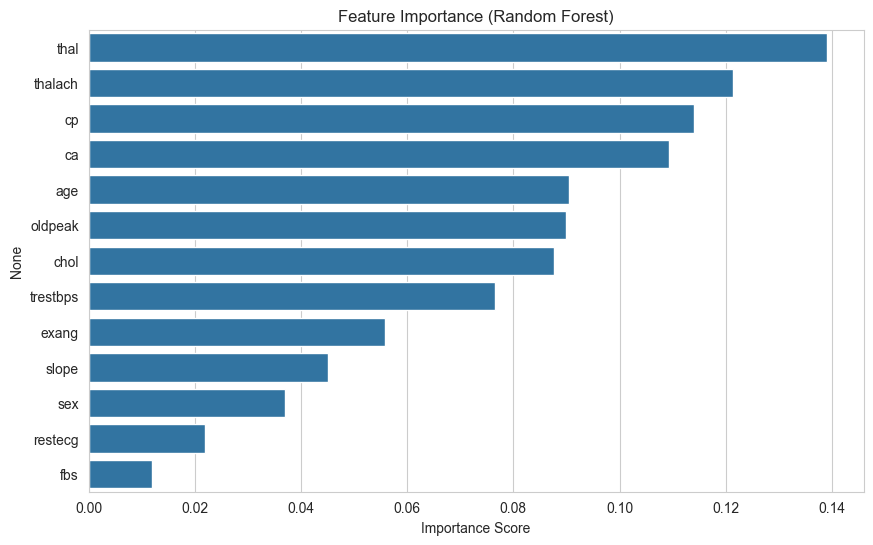

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

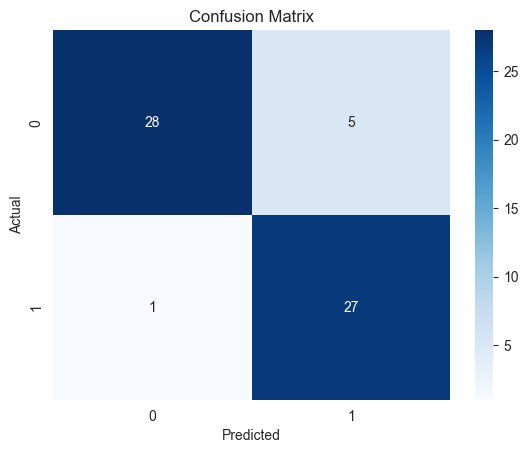

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [12]:
y_pred = rf.predict(X_test)
errors = X_test.copy()
errors['true'] = y_test
errors['pred'] = y_pred
errors['correct'] = (y_test == y_pred)
misclassified = errors[errors['correct'] == False]
print(f"Misclassified samples: {len(misclassified)} out of {len(X_test)}")
misclassified.head()

Misclassified samples: 6 out of 61


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,true,pred,correct
271,66.0,1.0,4.0,160.0,228.0,0.0,2.0,138.0,0.0,2.3,1.0,0.0,6.0,0,1,False
196,69.0,1.0,1.0,160.0,234.0,1.0,2.0,131.0,0.0,0.1,2.0,1.0,3.0,0,1,False
33,59.0,1.0,4.0,135.0,234.0,0.0,0.0,161.0,0.0,0.5,2.0,0.0,7.0,0,1,False
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,0.0,7.0,0,1,False
66,60.0,1.0,3.0,140.0,185.0,0.0,2.0,155.0,0.0,3.0,2.0,0.0,3.0,1,0,False


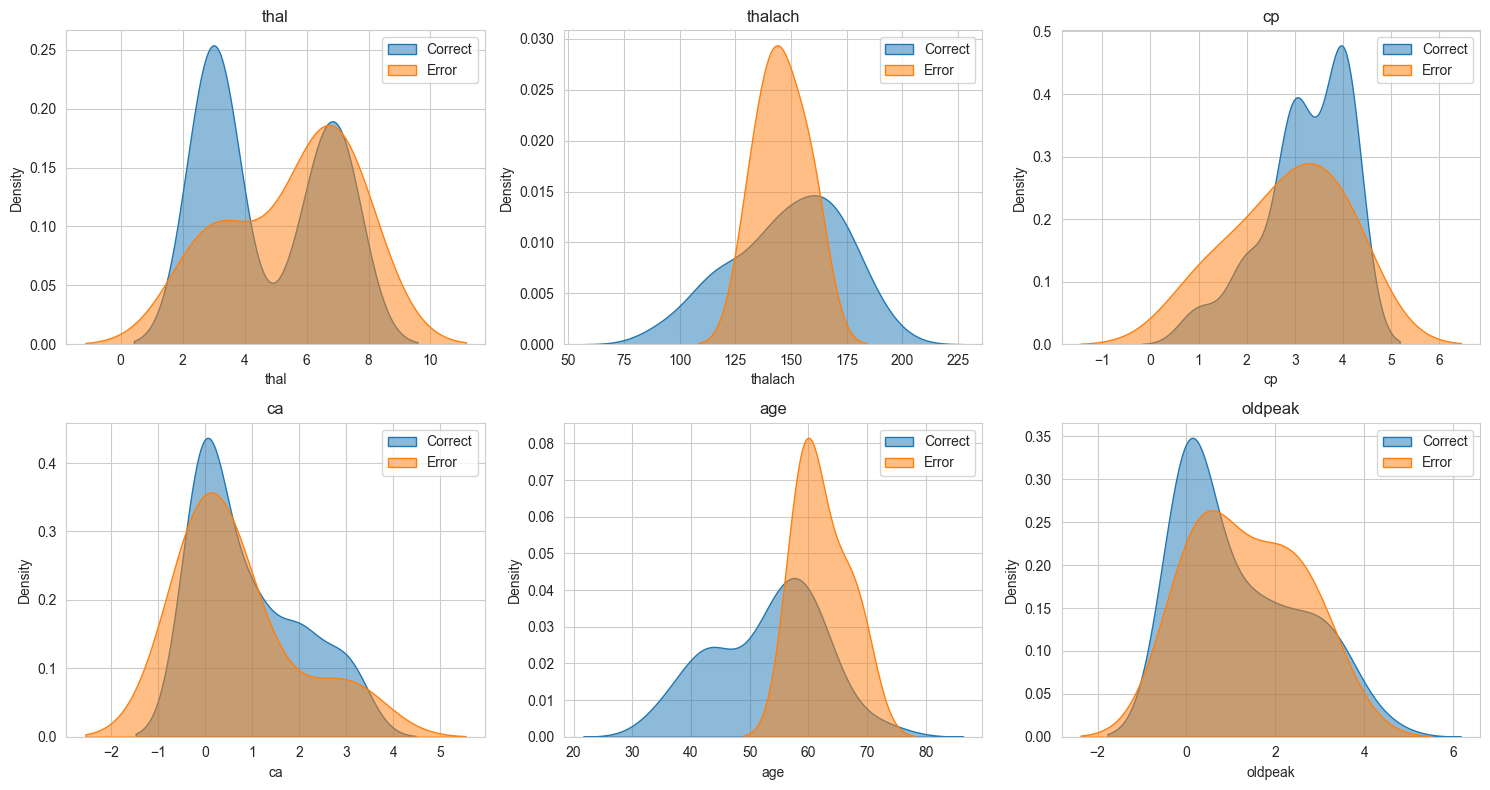

In [13]:
# Cell 13 - Compare feature distributions for correct vs incorrect predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
top_features = feat_imp.head(6).index
for i, feat in enumerate(top_features):
    sns.kdeplot(data=errors[errors['correct']==True], x=feat, label='Correct', ax=axes[i], fill=True, alpha=0.5)
    sns.kdeplot(data=errors[errors['correct']==False], x=feat, label='Error', ax=axes[i], fill=True, alpha=0.5)
    axes[i].set_title(feat)
    axes[i].legend()
plt.tight_layout()
plt.show()